# Apuntes Hadoop: Programar en Hadoop utilizando Streaming Hadoop

> Esta es una de las 2 formas de programar directamente en Hadoop para hacer uso del motor MapReduce.
>
> En ambos casos programaremos en **Python**

Es una herramienta dentro de Hadoop, que permite crear trabajos/aplicaciones MapReduce utilizando **cualquier tipo de script para los procesos *mappers y reducers*, sin importar su codio de programacion** 

> La unica regla que deben cumplir los scripts es que *los datos de entrada y salida usen la entrada estandar de Hadoop Streaming*

Cuando lanzas un trabajo, se reservan recursos en el cluster para crear los elementos necesarios del proceso: los mappers y reducers que ejecutaran el script indicado por el usuario para hacer el trabajo.

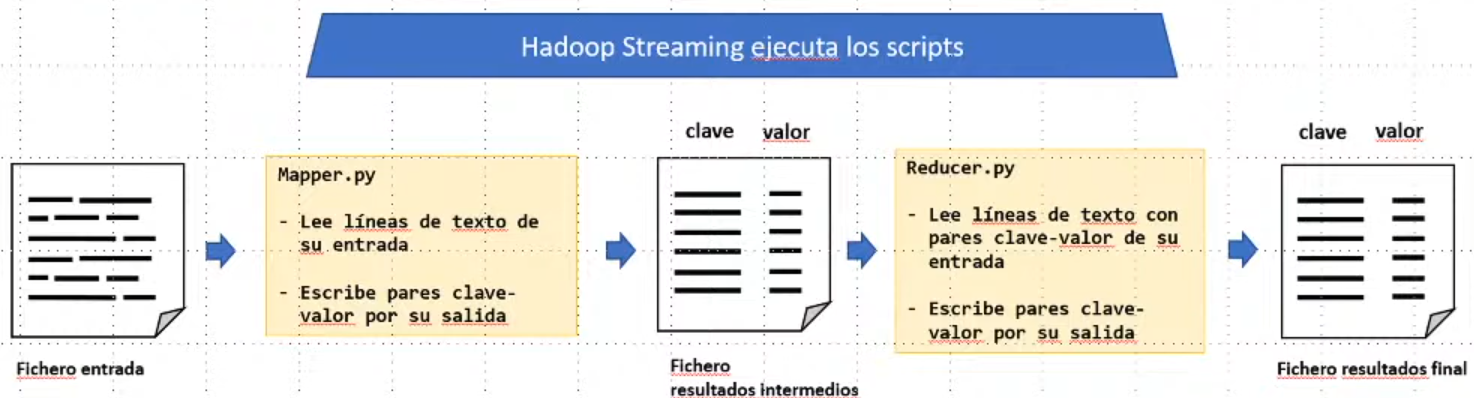


## 0. Conceptos previos para programar Mappers

> En las 2 formas de programar, **siempre se programaran *mappers* y *reducers***

Recordemos que una funcion Map permite **aplicar una funcion a los datos y generar valores intermedios interpretables para los *reducers*** y tiene 2 caracteristicas esenciales:

- Recibe una tupla, con un identificador y un valor
- Genera una lista de tuplas formado por la clave y el valor

En esta parte, **lo que nos interesa definir son los valores de entrada** ya que el identificador nos lo proporcionara el paso previo (*splitter*).

> El identificador generalmente es un elemento tipo [posicion] del dato dentro del conjunto.

## 0. Conceptos previos para programar Reducers

Recordemos que una funcion Reduce permite **aplicar una funcion a una lista con claves de entrada y de valores intermedios asociados a esa clave, para generar una lista o mas de resultados finales con una clave y un valor**. Tiene estas caracteristicas:

- No deben generarse pares con claves repetidas
- El contenido de las claves y valores puede ser cualquiera, no tiene porque coincidir con las de entrada.

En esta parte, **lo que nos interesa son las claves de entrada** ya que es lo que va a permitir realizar las listas con los valores que tengan la misma clave.

# 1. Iniciandonos en la herramienta

El modo en el que utilizamos la herramienta es sencilla, nos permite asignarle programas y unos datos sobre los que lo ejecutara, haciendo que los recursos del cluster se adapten al trabajo.

Necesitaremos entonces:

- **Crear los scripts/programas para el *Mapper***
- **Crear los scripts/programas para el *Reducer***
- **Proporcionar los datos de entrada**

Para que se ejecute correctamente hay que tener en cuenta:

- 1º los programas **son distintos e independientes**
- 2º el *mapper* ha de **leer datos de entrada y realizar la funcion que consideremos, para finalmente escribir los resultados en un formato clave - valor en formato texto tabulado**
> (mediante un print)
- 3º el *reducer* ha de **leer los resultados clave - valor en un formato texto tabulado, realizar la funcion que consideremos y los resultados finales sean una tupla por linea con un formato clave - valor tabulado**

## Ejemplo: Ejercicio de contar palabras

##### 0º Error al lanzar el HDFS

Puede pasar que al lanzar el sistema de ficheros en el terminal, recibas un mensaje parecido a este:

bigdata@bigdata-VirtualBox:~$ hdfs fs -cat /user/bigdata/U12/datos/resultados_ficheros_e01/part-00000
Unknown command: fs 
Usage: hdfs COMMAND
The flags available are a subset of the POSIX ones, but should behave similarly.

Valid commands:
  ls [-lah] [FILE]...
  rm [-rf] FILE...
  mv [-nT] SOURCE... DEST
  mkdir [-p] FILE...
  touch [-c] FILE...
  chmod [-R] OCTAL-MODE FILE...
  chown [-R] OWNER[:GROUP] FILE...
  cat SOURCE...
  head [-n LINES | -c BYTES] SOURCE...
  tail [-n LINES | -c BYTES] SOURCE...
  du [-sh] FILE...
  checksum FILE...
  get SOURCE [DEST]
  getmerge SOURCE DEST
  put SOURCE DEST
  df [-h]
  truncate SIZE FILE

En este caso **utiliza *hadoop* en vez de *hdfs* en la sentencia**

bigdata@bigdata-VirtualBox:~$ hadoop fs -cat /user/bigdata/U12/datos/resultados_ficheros_e01/part-00000

##### 1º Programamos en Python un script para el *mapper*, que nos permite contar palabras de los ficheros.

Tiene una caracteristicas comunes:

- Hay que importar la libreria *sys* para poder configurar **la entrada estandar y los errores estandar** para que Hadoop pueda gestionar los datos

> Recuerda: ***La unica regla que deben cumplir los scripts es que los datos de entrada y salida usen la entrada estandar de Hadoop Streaming***

- Hay que crear **gestion de excepciones** para evitar que el programa se bloquee.
- Hay que realizar **un print con cada posicion (clave y valor) y *tabulado*** para la salida de valores intermedios
> Para tabular se escribe \t

In [ ]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-
# Importamos sys, para que podamos habilitar las funciones de entrada y de errores estandar del sistema (sys.stdin y sys.stderr)
import sys
"""
Ejemplo de proceso *mapper* 
para ejecutar con Hadoop Streaming
"""

# Leer línea a línea de la entrada estándar (sys.stdin)
for linea in sys.stdin:
    # Generamos un gestor de excepciones para la lectura de lineas y asi evitar que se bloquee.
    try:
        # Troceamos la linea por los espacios en blanco para obtener una lista de palabras
        palabras = linea.split()
        # Iterar cada palabra
        for palabra in palabras:
            # Generamos una pareja clave-valor que será la entrada del Reducer. La clave es la palabra y el valor es la unidad (1).
            # El formato para la salida es simplemente escribir en cada línea primero la clave (palabra) y después el valor, separados por un tabulador.
            print('{0}\t{1}'.format(palabra, 1))
            print(f'DEBUG: Emitted ({palabra}, 1)', file=sys.stderr)
    except Exception as e:
        print(f'DEBUG: Error processing line: {linea}, Error: {str(e)}', file=sys.stderr)

##### 1.1º Realizar el mismo programa pero que depura mejor el texto

El anterior codigo se puede mejorar, **para hacer que no tenga en cuenta caracteres extraños o no alfanumericos**

Hay una 1º opcion que se puede realizar mediante un ***.replace("caracter que queremos eliminar", "")*** sin embargo el problema es que **sirve para 1 caracter concreto** y habria que concatenar varias funciones.

Una 2º opcion es coger la opcion anterior e incluir un bucle *for* para todos los caracteres que indiquemos

> ***for x in".,_:;+-/?":***
>
> >***variable = variable.replace("x", "")***

Sin embargo es igual de tedioso o poco escalable.

De modo que el modo mas adecuado de realizar esto es haciendo uso de ***expresiones regulares*** (un patron de caracteres que queremos detectar), hay que tener en cuenta estas 3 cosas:

- 1º lugar debemos importar el modulo para ello:

> ***import re***

- 2º lugar utilizaremos el modulo *re.findall()* que permite encontrar todas las veces que ocurre un patron en una cadena de texto.

- 3º lugar existen codigos de patrones definidos, por ejemplo, para los caracteres no alfanumericos, aqui indico algunos

> ***"\W"*** Representa todo lo que sea un **caracter no alfanumerico** (espacios, comas, puntos,...)
> 
> ***^"cualquier caracter"*** Representa **lo contrario al caracter que le pongamos al lado**
>
> ***"cualquier caracter"+*** Representa **cualquier secuencia que ocurra 1 o mas veces**

Si combinamos todo y generamos esta sentencia:

> ***import re***
>
> ***re.findall("[^\W]+", "cadena de texto a analizar")***

**Obtendremos que separa todas las palabras o caracteres sueltos alfanumericos**


In [ ]:
# Leer línea a línea de la#!/usr/bin/python3
# -*- coding: utf-8 -*-
# Importamos sys, para que podamos habilitar las funciones de entrada estandar del sistema (sys.stdin y sys.stderr)
import sys
"""
Ejemplo de proceso *mapper* 
para ejecutar con Hadoop Streaming
"""

# Leer línea a línea de la entrada estándar (sys.stdin)
for linea in sys.stdin:
    # Generamos un gestor de excepciones para la lectura de lineas y asi evitar que se bloquee.
    try:
    # Troceamos la linea usando una expresión regular
        # [] indica un conjunto de caracteres
        # ^ aquí significa "excepto"
        # \W representa "caracteres no alfanuméricos" (espacios, puntuación...)
        # \d representa "caracteres numéricos"
        # + significa "1 o más caracteres"
    # La expresión regular significa cualquier secuencia de caracteres que no contenga  números ni espacios ni signos de puntuación
        palabras = re.findall("[^\W\d]+", linea)
        # Iterar cada palabra
        for palabra in palabras:
            # Generamos una pareja clave-valor que será la entrada del Reducer. La clave es la palabra y el valor es la unidad (1).
            # El formato para la salida es simplemente escribir en cada línea primero la clave (palabra) y después el valor, separados por un tabulador.
            # Convertimos los caracteres a minúsculas con lower()
            print('{0}\t{1}'.format(palabra.lower(), 1))
            print(f'DEBUG: Emitted ({palabra}, 1)', file=sys.stderr)
    except Exception as e:
        print(f'DEBUG: Error processing line: {linea}, Error: {str(e)}', file=sys.stderr) entrada estándar

##### 2º Programamos en Python un script para el *reducer*, que nos permite sumar el conteo de las palabras en base a su clave

Tiene una caracteristicas comunes:

- Hay que importar la libreria *sys* para poder configurar **la entrada estandar y los errores estandar** para que Hadoop pueda gestionar los datos

> Recuerda: ***La unica regla que deben cumplir los scripts es que los datos de entrada y salida usen la entrada estandar de Hadoop Streaming***

- Hay que crear **gestion de excepciones** para evitar que el programa se bloquee.
- Hay que cambiar el tipo de dato **la lista de valores a *int***
- Hay que **iterar para contabilizar los valores en base a sus claves.**
- Hay que realizar **un print con cada posicion (clave y valor) y *tabulado*** para la salida de reultados finales
> Para tabular se escribe \t

In [ ]:
#!/usr/bin/python3
# -*- coding: utf-8 -*-
# Importamos sys, para que podamos habilitar las funciones de entrada estandar del sistema (sys.stdin)

import sys
"""
Ejemplo de proceso *reducer* 
para ejecutar con Hadoop Streaming
"""

# Creamos un Diccionario para almacenar el conteo de cada palabra
conteo_palabras = {}

# Leemos línea a línea de la entrada estándar
for linea in sys.stdin:
    # Dividimos la linea por el tabulador para obtener la clave (palabra) y el valor (conteo)
    palabra, conteo = linea.split('\t')
    # La entrada es una cadena de texto que tenemos que convertir el conteo a un valor numérico
    conteo = int(conteo)
    # Comprobamos si la nueva palabra ya la habíamos visto antes (está ya incluida en nuestro diccionario)
    if palabra in conteo_palabras:
        # Actualizamos el contador si estaba
        conteo_palabras[palabra] = conteo_palabras[palabra] + conteo
    else:
        # si no estaba, la añadimos con el conteo que hemos leído
        conteo_palabras[palabra] = conteo

# Cuando ya hemos procesado todas las palabras de entrada imprimimos los conteos finales como resultado
for palabra in sorted(conteo_palabras.keys()):
    print("{0}\t{1}".format(palabra, conteo_palabras[palabra]))

##### 3º Activar Hadoop Streaming e indicar las rutas para ejecutar el programa *MapReduce*

Una vez realizados los scripts hay que juntar todo el codigo para ejecutarlo en el terminal

Primero **nos ubicamos en la carpeta donde lo vamos a ejecutar o donde se albergan los scripts**:

>

Despues **crearemos una unica sentencia para lanzar la herramienta y ejecutar los scripts**, se compondra:

- 1º Parte donde activaremos la herramienta
- 2º Parte donde se indican las rutas para los ficheros del *mapper* y para del *reducer*
- 3º Parte donde le indicaremos **que fichero es el mapper y cual es el reducer**
- 4º Parte donde le indicaremos **las rutas de los ficheros HDFS** de entrada que leera
- 5º Parte donde le indicaremos **las rutas donde queremos que guarde los resultados**

1º La sentencia **para activar la herramienta**:

> ***hadoop jar $HADOOP_HOME/share/hadoop/tools/lib/hadoop-streaming*.jar***

2º la sentencia para indicar **las rutas de los ficheros del *mapper* y el *reducer***:

> ***-file ./"ubicacion del archivo *maper*" -file ./"ubicacion del archivo *reducer*"***

3º la sentencia para indicar **que fichero es el mapper y cual el reducer**:

> ***-mapper "nombre del fichero".py -reducer "nombre del fichero".py***

4º la sentencia para indicar **las rutas de los ficheros HDFS**, requiere de una accion previa:

Debemos asegurarnos que los ficheros estan en el sistema HDFS dentro de Hadoop, para ello haremos uso de la sentencia ***hdfs dfs -ls /"ubicacion/ carpeta donde se encuentran los archivos""***

Una vez estamos seguro de ello, utilizaremos esta sentencia:

> ***-input /"ubicacion del fichero a leer, tal y como esta registrado en el HDFS"***

5º la sentencia para indicar **las rutas de los ficheros con los resultados**, (requiere que sea una ubicacion en HDFS)

> ***-output /"ubicacion del fichero resultado"/"nombre del fichero con los resultados"***

hadoop jar $HADOOP_HOME/share/hadoop/tools/lib/hadoop-streaming*.jar -file ./U12_hadoop_streaming_mapper.py -file ./U12_hadoop_streaming_reducer.py -mapper U12_hadoop_streaming_mapper.py -reducer U12_hadoop_streaming_reducer.py -input /user/bigdata/U12/datos/*.txt -output /user/bigdata/U12/datos/resultados_ficheros_e01

##### 4º Comprobar resultados del fichero generado en el HDFS

Una vez hayamos ejecutado la sentencia completa, tras un rato de carga, **si comprobamos la ubicacion del fichero en HDFS** obtendremos al menos 2 ficheros:

- El 1º fichero, **no tendra datos y solo indicara como ha acabado la ejecucion**
- El 2º (o mas) **ficheros con resultados**
> El nº de ficheros de resultados dependera de la complejidad del trabajo (mas reducers, mas ficheros) o del tamaño de los archivos (mas datos, mas ficheros resultado)

hadoop fs -ls /user/bigdata/U12/datos/resultados_ficheros_e01
Found 2 items
-rw-r--r--   1 bigdata supergroup          0 2026-01-28 12:44 /user/bigdata/U12/datos/resultados_ficheros_e01/_SUCCESS
-rw-r--r--   1 bigdata supergroup      63449 2026-01-28 12:44 /user/bigdata/U12/datos/resultados_ficheros_e01/part-00000

##### 5º Descargar los ficheros generados en el HDFS

Por ultimo podemos descargar los ficheros para tener una copia local, para ello hay que seguir estos pasos:

- *Opcional*: Otorgar permisos completos (lectura, escritura y ejecución) a todos los usuarios (propietario, grupo y otros) sobre el directorio output

> ***hadoop fs -chmod -R 777 ./"nombre de la ubicacion donde esta el fichero"***

- Utilizar una sentencia que copie los archivos a una ubicacion local

>***hadoop fs -get /"ubicacion del fichero con resultados en HDFS" /"ubicacion doonde se descargara el archivo"/"nombre del archivo"."extension"***

hadoop fs -get /user/bigdata/U12/datos/resultados_ficheros_e02/part-00000 /home/bigdata/Curso/U12_Hadoop/output/resultados_finales_e02.tab